In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
pd.set_option("display.max_columns", 30)

df = pd.read_csv("data/Digital_Payments_Data.csv")
print(df.shape)
df.head()

(10057, 25)


,Transaction_ID,Transaction_Timestamp,Customer_ID,Date_of_Birth,Gender,Sector,Store_or_Service_ID,Store_Type,Payment_Method,Card_Type,Card_Category,Wallet_Provider,Transaction_Amount_GBP,Payment_Status,Transaction_Channel,Government_Service,Crypto_Type,Spending_Limit_Used,Customer_Segment,Store_or_Service_Name,Device_Type,Promo_Code,App_Version,Merchant_Category_Code,Location
0,T00001,21-08-2025 12:37:21,641,15-08-1953,Female,Government Services,Citizens Service Center,Trial,Card,Visa,Prepaid,NaN,120.78,Failed,Online,Yes,NaN,No,Low,Citizens Service Center,Laptop,NONE,1.0.0,186,Kingsport
1,T00002,06-03-2025 10:17:12,1904,28-05-1968,Male,Retail,MegaGadgets,Control,Card,Mastercard,Prepaid,NaN,254.83,Failed,In_Store,No,NaN,No,NaN,MegaGadgets,Laptop,WINTER25,3.1.0,627,Oakridge
2,T00003,26-06-2025 01:27:45,256,09-11-1984,Male,Entertainment,CinemaWorld,Trial,Digital_Wallet,NaN,NaN,Wish,4.64,Failed,In_App,No,NaN,No,Low,CinemaWorld,Computer,SUMMER24,3.2.1,800,Fairview
3,T00004,02-02-2024 21:34:21,1244,02-05-1960,Male,Retail,FashionPoint,Control,Cryptocurrency,NaN,NaN,NaN,88.23,Failed,In_App,No,Bitcoin,No,Medium,FashionPoint,Laptop,NONE,2.2.0,152,Stonebridge
4,T00005,19-01-2025 20:56:09,777,11-11-1967,Female,Retail,FreshFoods,Control,Card,Mastercard,Prepaid,NaN,125.63,Failed,In_Store,No,NaN,No,Low,FreshFoods,Mobile,WINTER25,2.1.0,594,Kingsport


## 1. Data Cleaning

In [2]:
df["Transaction_Timestamp"] = pd.to_datetime(df["Transaction_Timestamp"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Transaction_Timestamp"])

for col in ["Customer_Segment", "Device_Type", "Promo_Code", "App_Version"]:
    df[col] = df[col].fillna("Unknown")
for col in ["Card_Type", "Card_Category", "Wallet_Provider", "Crypto_Type"]:
    df[col] = df[col].fillna("None")

df["Is_Successful"] = (df["Payment_Status"] == "Successful").astype(int)
df["Year"] = df["Transaction_Timestamp"].dt.year
df["Month"] = df["Transaction_Timestamp"].dt.month
df["MonthPeriod"] = df["Transaction_Timestamp"].dt.to_period("M").astype(str)
df["DayOfWeek"] = df["Transaction_Timestamp"].dt.day_name()
df["DayOfWeekNum"] = df["Transaction_Timestamp"].dt.dayofweek
df["Hour"] = df["Transaction_Timestamp"].dt.hour
df["Quarter"] = df["Transaction_Timestamp"].dt.quarter

mobile_methods = {"Digital_Wallet", "QR_Payment", "Virtual_Card", "Cryptocurrency"}
df["Payment_Group"] = np.where(df["Payment_Method"].isin(mobile_methods), "Mobile/Digital Payment", "Card/Bank Payment")

print(f"Rows: {len(df)}  |  Date range: {df['Transaction_Timestamp'].min()} to {df['Transaction_Timestamp'].max()}")
df[["Transaction_Timestamp","Payment_Method","Payment_Group","Transaction_Channel","Transaction_Amount_GBP"]].head()

Rows: 10057  |  Date range: 2024-01-01 00:07:24 to 2025-12-31 22:15:37


,Transaction_Timestamp,Payment_Method,Payment_Group,Transaction_Channel,Transaction_Amount_GBP
0,2025-08-21 12:37:21,Card,Card/Bank Payment,Online,120.78
1,2025-03-06 10:17:12,Card,Card/Bank Payment,In_Store,254.83
2,2025-06-26 01:27:45,Digital_Wallet,Mobile/Digital Payment,In_App,4.64
3,2024-02-02 21:34:21,Cryptocurrency,Mobile/Digital Payment,In_App,88.23
4,2025-01-19 20:56:09,Card,Card/Bank Payment,In_Store,125.63


## 2. Exploratory Data Analysis — Trends

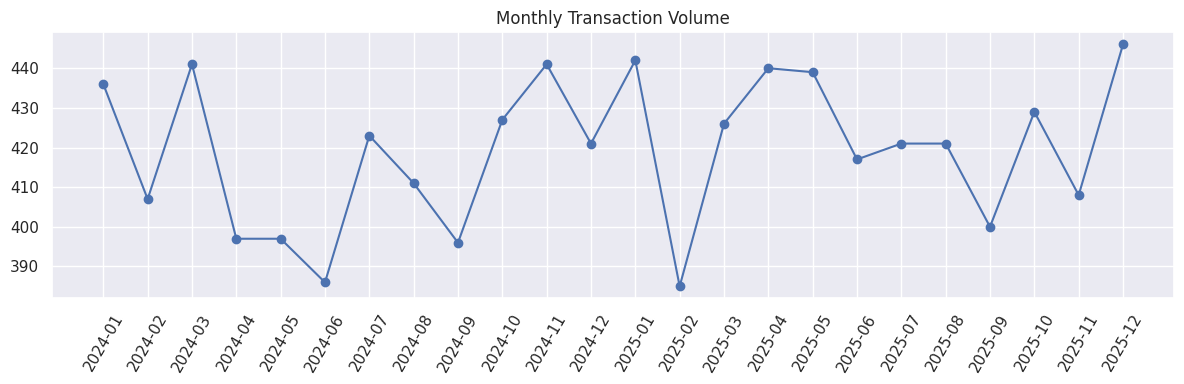

,MonthPeriod,Transaction_Count,Total_Value,Avg_Value,Success_Rate
19,2025-08,421,103749.25,246.435273,0.736342
20,2025-09,400,101875.68,254.689200,0.760000
21,2025-10,429,117334.89,273.507902,0.785548
22,2025-11,408,106003.19,259.811740,0.786765
23,2025-12,446,112451.62,252.133677,0.834081


In [3]:
monthly = df.groupby("MonthPeriod").agg(
    Transaction_Count=("Transaction_ID", "count"),
    Total_Value=("Transaction_Amount_GBP", "sum"),
    Avg_Value=("Transaction_Amount_GBP", "mean"),
    Success_Rate=("Is_Successful", "mean"),
).reset_index().sort_values("MonthPeriod")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(monthly["MonthPeriod"], monthly["Transaction_Count"], marker="o")
ax.set_title("Monthly Transaction Volume")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()
monthly.tail()

## 3. Peak Season Analysis

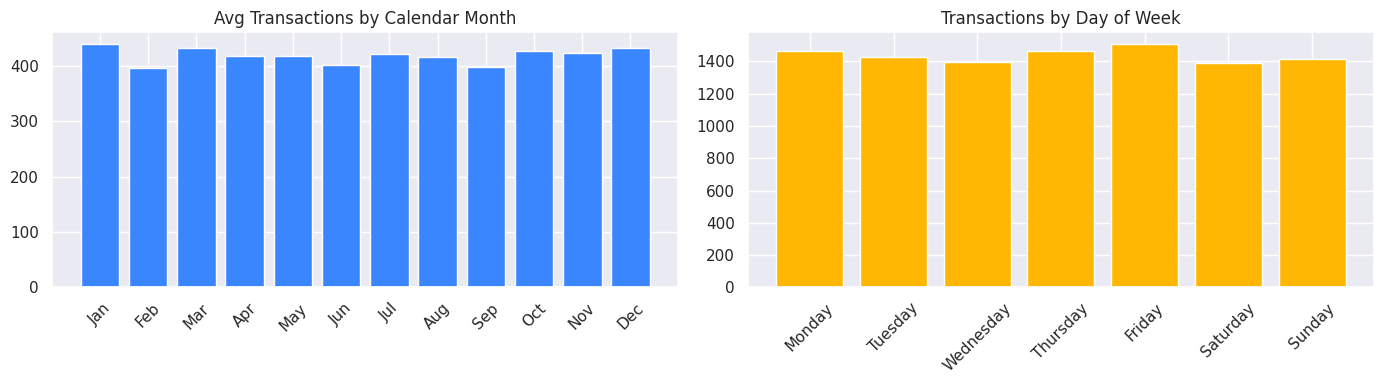

Peak month: 2025-12
Lowest month: 2025-02


In [4]:
monthly["month_num"] = pd.PeriodIndex(monthly["MonthPeriod"], freq="M").month
seasonal_avg = monthly.groupby("month_num")["Transaction_Count"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].bar([month_names[mn-1] for mn in seasonal_avg.index], seasonal_avg.values, color="#3a86ff")
axes[0].set_title("Avg Transactions by Calendar Month")
axes[0].tick_params(axis='x', rotation=45)

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts = df["DayOfWeek"].value_counts().reindex(dow_order)
axes[1].bar(dow_counts.index, dow_counts.values, color="#ffb703")
axes[1].set_title("Transactions by Day of Week")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Peak month:", monthly.loc[monthly['Transaction_Count'].idxmax(), 'MonthPeriod'])
print("Lowest month:", monthly.loc[monthly['Transaction_Count'].idxmin(), 'MonthPeriod'])

## 4. Channel & Payment Method Preference

Payment_Group
Mobile/Digital Payment    8090
Card/Bank Payment         1967
Name: count, dtype: int64 

Payment_Group
Mobile/Digital Payment    0.804415
Card/Bank Payment         0.195585
Name: count, dtype: float64


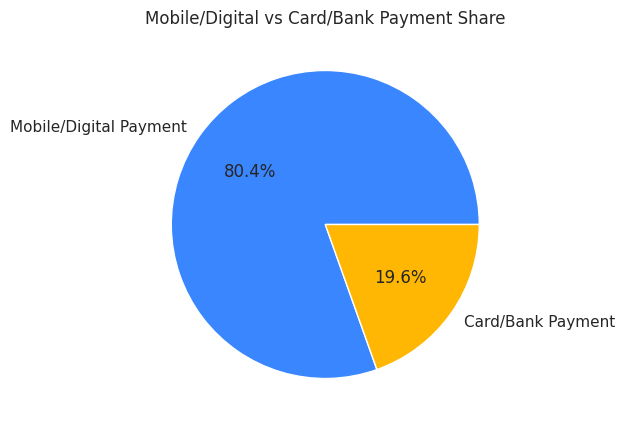

In [5]:
group_counts = df["Payment_Group"].value_counts()
print(group_counts, "\n")
print(group_counts / group_counts.sum())

fig, ax = plt.subplots(figsize=(5,5))
ax.pie(group_counts.values, labels=group_counts.index, autopct="%1.1f%%",
       colors=["#3a86ff","#ffb703"])
ax.set_title("Mobile/Digital vs Card/Bank Payment Share")
plt.show()

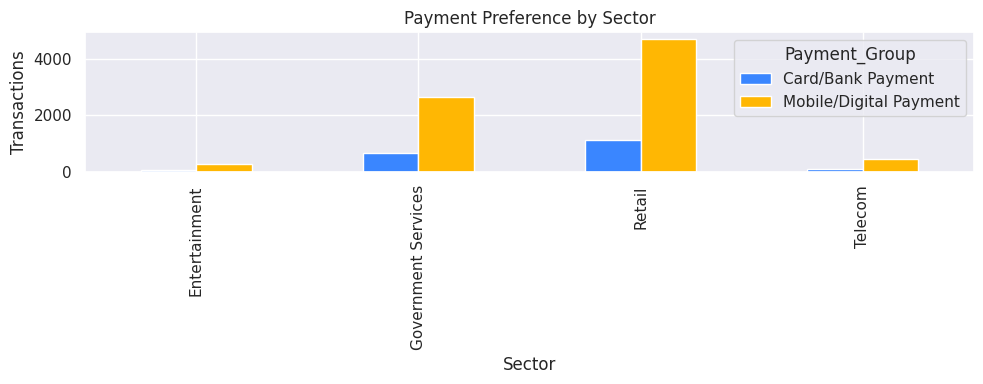

Payment_Group,Card/Bank Payment,Mobile/Digital Payment
Sector,,
Entertainment,72,287
Government Services,674,2645
Retail,1117,4695
Telecom,104,463


In [6]:
sector_pref = pd.crosstab(df["Sector"], df["Payment_Group"])
sector_pref.plot(kind="bar", figsize=(10,4), color=["#3a86ff","#ffb703"])
plt.title("Payment Preference by Sector")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()
sector_pref

## 5. Model A — Forecasting Future Transaction Volume


R^2 = 0.793   MAE = 7.4


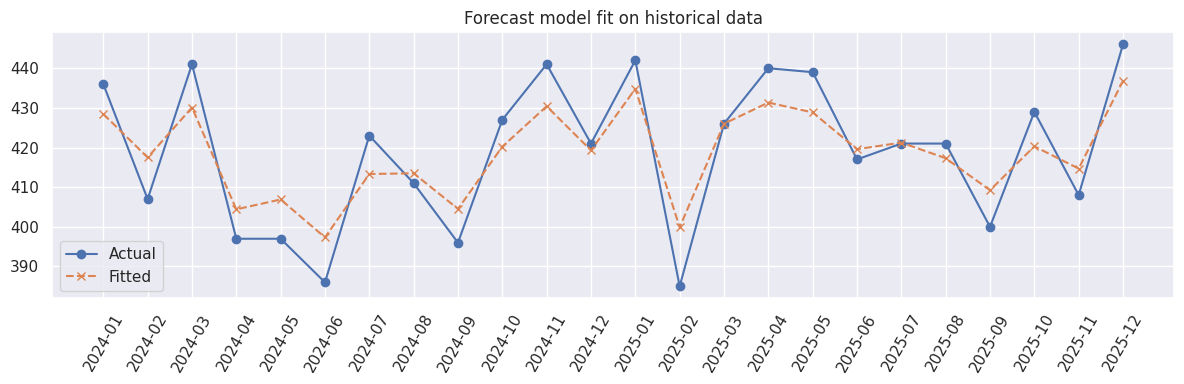

In [7]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score
import joblib, os

m = monthly.reset_index(drop=True).copy()
m["t"] = np.arange(len(m))
m["lag_1"] = m["Transaction_Count"].shift(1).bfill()
m["lag_2"] = m["Transaction_Count"].shift(2).bfill()

X = m[["t","month_num","lag_1","lag_2"]]
y = m["Transaction_Count"]

forecast_model = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
forecast_model.fit(X, y)
preds = forecast_model.predict(X)
print(f"R^2 = {r2_score(y, preds):.3f}   MAE = {mean_absolute_error(y, preds):.1f}")

plt.figure(figsize=(12,4))
plt.plot(m["MonthPeriod"], y, label="Actual", marker="o")
plt.plot(m["MonthPeriod"], preds, label="Fitted", marker="x", linestyle="--")
plt.xticks(rotation=60)
plt.legend()
plt.title("Forecast model fit on historical data")
plt.tight_layout()
plt.show()

In [8]:
# Recursively forecast the next 6 months
def forecast_future(n_months=6):
    last_t, last_period = m["t"].iloc[-1], pd.Period(m["MonthPeriod"].iloc[-1], freq="M")
    lag1, lag2 = m["Transaction_Count"].iloc[-1], m["Transaction_Count"].iloc[-2]
    rows = []
    for i in range(1, n_months+1):
        period = last_period + i
        Xf = pd.DataFrame([[last_t+i, period.month, lag1, lag2]], columns=["t","month_num","lag_1","lag_2"])
        pred = forecast_model.predict(Xf)[0]
        rows.append({"MonthPeriod": str(period), "Predicted_Transactions": round(pred)})
        lag2, lag1 = lag1, pred
    return pd.DataFrame(rows)

forecast_future(6)

,MonthPeriod,Predicted_Transactions
0,2026-01,406
1,2026-02,432
2,2026-03,420
3,2026-04,433
4,2026-05,417
5,2026-06,426


## 6. Model B — Channel Preference Classifier (Mobile/Digital vs Card/Bank)

Accuracy: 0.6053677932405567
Classes: ['Card/Bank Payment', 'Mobile/Digital Payment']


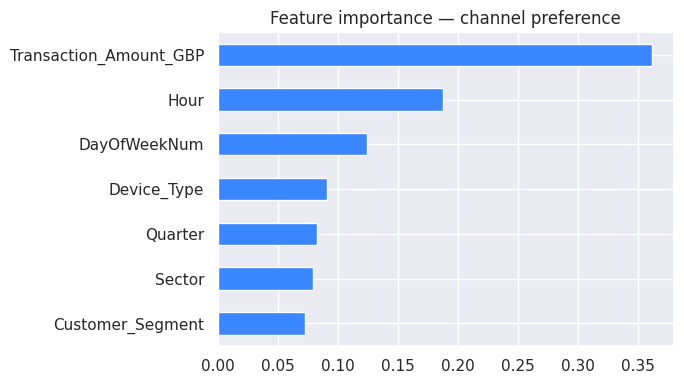

In [9]:
features = ["Sector","Customer_Segment","Device_Type","Transaction_Amount_GBP","DayOfWeekNum","Hour","Quarter"]
data = df[features + ["Payment_Group"]].dropna()

encoders = {}
Xc = data[features].copy()
for col in ["Sector","Customer_Segment","Device_Type"]:
    le = LabelEncoder()
    Xc[col] = le.fit_transform(Xc[col].astype(str))
    encoders[col] = le

y_le = LabelEncoder()
yc = y_le.fit_transform(data["Payment_Group"])

Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
channel_model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced")
channel_model.fit(Xtr, ytr)
print("Accuracy:", accuracy_score(yte, channel_model.predict(Xte)))
print("Classes:", list(y_le.classes_))

importances = pd.Series(channel_model.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", figsize=(7,4), color="#3a86ff", title="Feature importance — channel preference")
plt.tight_layout()
plt.show()

## 7. Model C — Specific Payment Method Classifier



In [ ]:
features2 = ["Sector","Customer_Segment","Device_Type","Transaction_Amount_GBP","DayOfWeekNum","Hour"]
data2 = df[features2 + ["Payment_Method"]].dropna()

encoders2 = {}
Xm = data2[features2].copy()
for col in ["Sector","Customer_Segment","Device_Type"]:
    le = LabelEncoder()
    Xm[col] = le.fit_transform(Xm[col].astype(str))
    encoders2[col] = le

y_le2 = LabelEncoder()
ym = y_le2.fit_transform(data2["Payment_Method"])

Xtr2, Xte2, ytr2, yte2 = train_test_split(Xm, ym, test_size=0.2, random_state=42, stratify=ym)
method_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight="balanced")
method_model.fit(Xtr2, ytr2)
print("Accuracy:", accuracy_score(yte2, method_model.predict(Xte2)))
print("Classes:", list(y_le2.classes_))

Accuracy: 0.20825049701789264
Classes: ['Card', 'Cryptocurrency', 'Digital_Wallet', 'QR_Payment', 'Virtual_Card']


## 8. Save Models & Aggregates for the Dashboard



In [11]:
os.makedirs("models", exist_ok=True)
joblib.dump(forecast_model, "models/forecast_model.pkl")
joblib.dump(m, "models/forecast_history.pkl")
joblib.dump(channel_model, "models/channel_model.pkl")
joblib.dump(encoders, "models/channel_encoders.pkl")
joblib.dump(y_le, "models/channel_target_encoder.pkl")
joblib.dump(features, "models/channel_features.pkl")
joblib.dump(method_model, "models/method_model.pkl")
joblib.dump(encoders2, "models/method_encoders.pkl")
joblib.dump(y_le2, "models/method_target_encoder.pkl")
joblib.dump(features2, "models/method_features.pkl")
print("Saved all models to /models")

Saved all models to /models
